## Import lib

In [120]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader , TensorDataset
from torchvision.utils import save_image, make_grid
from torch.optim import Adam
import torch.nn.init as init

import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm

import copy
import seaborn as sns

from scipy.stats import norm
from sklearn.neighbors import KernelDensity, LocalOutlierFactor
from sklearn.decomposition import PCA

import pandas as pd
import tqdm

import pickle

# MI estimators
from utils.estimators import *

## Load data

In [29]:
dataset = {"none" :[], "rough":[] , "weight":[]}
for i in dataset.keys():
    for policy in range(3):
        dataset[i].append(np.load(f"data/eval/{i}-policy_{policy}-seed_0-rand_0.npy" , allow_pickle=True).item())
for key, value in dataset.items():
    dataset[key] = np.array(value)
print("Loaded data !")
dataset.keys()

Loaded data !


dict_keys(['none', 'rough', 'weight'])

In [42]:
dataset["none"][0]["data"].keys()

dict_keys(['state', 'action', 'vel', 'action_lowpass', 'pos_x', 'pos_y', 'yaw', 'fc', 'torque', 'reward'])

Performance measuring

In [ ]:
performance = {f"policy{n_policy}": {case: [] for case in dataset.keys()} for n_policy in range(3)}
max_distance = {f"policy{n_policy}": {case: [] for case in dataset.keys()} for n_policy in range(3)}

for policy in range(3):
    for case in dataset.keys():
        reward = np.sum(dataset[case][policy]["data"]['reward'], axis=0)
        performance[f"policy{policy}"][case] = reward
        max_pos_x = np.max(dataset[case][policy]["data"]['pos_x'], axis=0)
        max_distance[f"policy{policy}"][case] = max_pos_x

print(performance.keys())  # Prints the policy keys
print(performance["policy0"].keys())  # Prints the case keys under "policy0"
print(max_distance.keys())  # Prints the policy keys
print(max_distance["policy0"].keys())  # Prints the case keys under "policy0"



dict_keys(['policy0', 'policy1', 'policy2'])
dict_keys(['none', 'rough', 'weight'])
dict_keys(['policy0', 'policy1', 'policy2'])
dict_keys(['none', 'rough', 'weight'])


In [176]:
def plot_performance(performance):
    num_col = len(performance.keys())  # Number of policies (columns)
    fig, axes = plt.subplots(1, num_col, figsize=(8, 6))
    pastel_colors = sns.color_palette("pastel", n_colors=num_col)
    case_colors = {case: pastel_colors[i] for i, case in enumerate(list(performance['policy0'].keys()))}
    for i, policy in enumerate(performance.keys()):
        ax = axes[i]  # Get the axis for this policy subplot
        box = ax.boxplot(
            [performance[policy][case] for case in performance[policy].keys()],  # List of data for each case
            tick_labels=list(performance[policy].keys()) ,vert=True, patch_artist=True,  # fill with color  # Set the tick labels to be the case names
        )
        for j, patch in enumerate(box['boxes']):
            case = list(performance[policy].keys())[j]  # Get the case corresponding to the current box
            patch.set_facecolor(case_colors[case])  # Set the color for the box based on the case

        for j, case in enumerate(performance[policy].keys()):
            x_vals = [j + 1 + np.random.normal(0, 0.1) for _ in performance[policy][case]]  # Jitter with normal noise
            ax.scatter(x_vals, performance[policy][case], alpha=0.8, s=5, label=case)
        ax.set_title(f"Performance for {policy}")
    plt.tight_layout()
    plt.show()

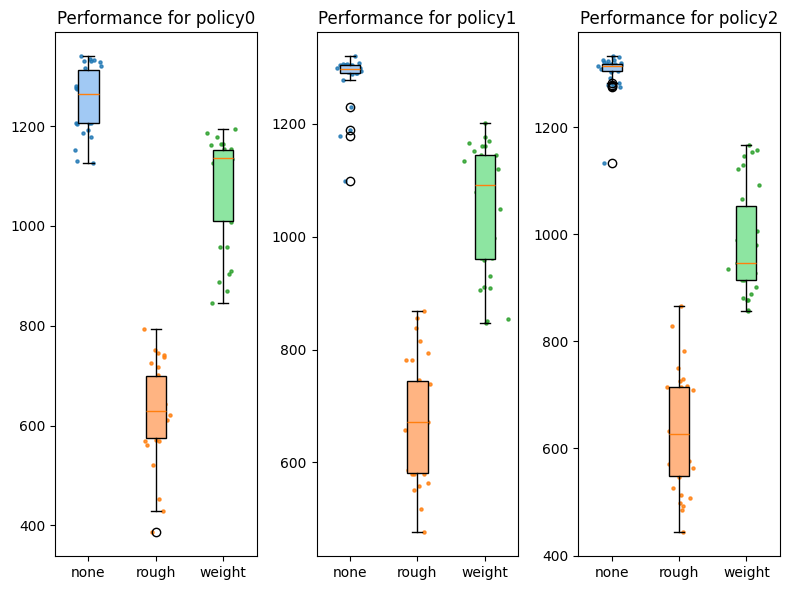

In [172]:
plot_performance(performance)

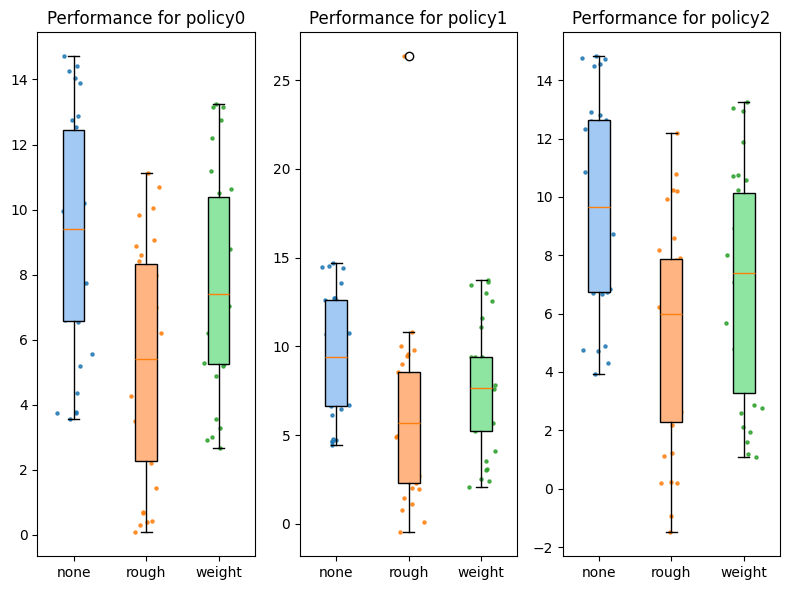

In [177]:
plot_performance(max_distance)